<h1> Import

In [1]:

from masterthesis.data.loaders import load_cell_dataframe
from masterthesis.data.datasets import subsampled_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset, make_observational_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears, run_dotears_test, run_dotears_test2

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot

import numpy as np


<h1> Single Cell

<h2> Data

In [2]:
cell_df = load_cell_dataframe()

# keep dynamic regimes
#cell_df = cell_df[cell_df["StepIndex"].isin([9, 17,18,19,20,21])]

# downsample
cell_df = cell_df.iloc[::10]

cell_df.head()


,CellID,CurrentData,VoltageData,TempData,StepIndex,CycleIndex,TimeData
0,GS3,0.0,4.197761,24.041702,9,1,0.0000
10,GS3,0.0,4.197698,24.023285,9,1,10.0003
20,GS3,0.0,4.196752,23.888824,9,1,20.0004
30,GS3,0.0,4.196815,23.962847,9,1,30.0001
40,GS3,0.0,4.196689,24.058426,9,1,40.0004


In [3]:
cols = ["CurrentData", "VoltageData", "TempData"]

groups = [
    [9, 11, 13, 15, 22],   # rest
    [10],                  # strong discharge
    [12],                  # medium discharge
    [14],                  # charge
    [17,18,19,20,21]       # dynamic experiments
]

env_df = subsampled_env_dict(cell_df, cols, groups, sort_by="StepIndex", max_samples_per_env=100, seed=42)
print(env_df[0].shape)
print(env_df[4].shape)

Group
0    226039
4     25862
1     12346
2      3455
3      3453
Name: count, dtype: int64
(100, 3)
(100, 3)


<h3> Preprocessing (scaling+noise)

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=True,
    noise_std=0.000001,
    seed=42,
)

print(env_data.keys())

dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
after scale: [1.66533454e-16 9.81277730e-01 7.85931024e-01]
after noise: [8.20664723e-07 9.81277764e-01 7.85930826e-01]
dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)])


<h3> Dataset

In [5]:
interventions = {
    0: [],     # rest = observational
    1: [0],    # discharge
    2: [0],    # discharge
    3: [0],    # charge
    4: [0],    # dynamic excitation
}
dataset = make_environment_dataset(env_data, interventions)

X_obs = np.vstack(list(env_data.values()))
dataset_obs = make_observational_dataset(X_obs)


In [6]:
print(dataset["X"].shape)
print(dataset["X"][:10])
print(dataset["X"].std(axis=0))     


(500, 3)
[[ 3.51015510e-01  1.36263299e+00 -2.90778642e-01]
 [ 3.51016536e-01 -2.40801100e-02 -1.25434536e+00]
 [ 3.51016592e-01 -8.86797385e-01 -4.13861762e-01]
 [ 3.51015556e-01  1.38698816e+00  5.93758159e-01]
 [ 3.51015255e-01  1.30172352e+00  2.64473754e+00]
 [ 3.51014451e-01  1.08286103e+00 -9.24488176e-02]
 [ 3.51014105e-01 -1.88783434e-03 -1.46762814e+00]
 [ 3.51014787e-01 -1.59239739e+00 -1.06993082e-01]
 [ 3.51014469e-01  1.75510105e+00 -4.10415065e-01]
 [ 3.51015389e-01  3.63972775e-01 -1.28587187e+00]]
[1.00000004 1.         0.99999996]


In [7]:
import pandas as pd

pd.DataFrame(dataset["X"], columns=cols).corr()

,CurrentData,VoltageData,TempData
CurrentData,1.000000,0.316371,-0.318340
VoltageData,0.316371,1.000000,-0.130298
TempData,-0.318340,-0.130298,1.000000


In [8]:
for k,v in env_data.items():
    print(k, v.shape)

0 (100, 3)
1 (100, 3)
2 (100, 3)
3 (100, 3)
4 (100, 3)


In [9]:
print(dataset['envs'])

{np.int64(0): array([[ 3.51015510e-01,  1.36263299e+00, -2.90778642e-01],
       [ 3.51016536e-01, -2.40801100e-02, -1.25434536e+00],
       [ 3.51016592e-01, -8.86797385e-01, -4.13861762e-01],
       [ 3.51015556e-01,  1.38698816e+00,  5.93758159e-01],
       [ 3.51015255e-01,  1.30172352e+00,  2.64473754e+00],
       [ 3.51014451e-01,  1.08286103e+00, -9.24488176e-02],
       [ 3.51014105e-01, -1.88783434e-03, -1.46762814e+00],
       [ 3.51014787e-01, -1.59239739e+00, -1.06993082e-01],
       [ 3.51014469e-01,  1.75510105e+00, -4.10415065e-01],
       [ 3.51015389e-01,  3.63972775e-01, -1.28587187e+00],
       [ 3.51014412e-01, -8.95308315e-01, -9.63821132e-01],
       [ 3.51013956e-01,  1.74251212e+00, -7.32492063e-01],
       [ 3.51015222e-01,  1.35045170e+00,  9.98247750e-01],
       [ 3.51015210e-01, -4.90011549e-01, -4.56162103e-01],
       [ 3.51014898e-01, -2.19644532e-01, -1.48671305e-01],
       [ 3.51014293e-01, -4.78777716e-01, -2.60260696e-01],
       [ 3.51015357e-01,  

<h2> PC

In [10]:
dag_pc = run_pc(dataset)
print(dag_pc)

  0%|          | 0/3 [00:00<?, ?it/s]

[[0 1 1]
 [1 0 0]
 [1 0 0]]


<h2> No-Tears

In [11]:
dag_notears = run_notears(dataset_obs)
print(dag_notears)

100%|██████████| 20/20 [00:02<00:00,  8.96it/s]

[[0 0 0]
 [0 0 0]
 [0 0 0]]


<h2> Third alg-Do Tears

In [12]:
dag_dotears = run_dotears_test(dataset, 0.05, 0.3)
print(dag_dotears)

[[0 0 0]
 [1 0 0]
 [1 0 0]]


In [13]:
dag_dotears2 = run_dotears_test2(dataset, 0.05, 0.3)
print(dag_dotears2)

[[0 1 1]
 [0 0 0]
 [0 0 0]]


<h2> Third alg- GIES

<h2> Compare/Results?

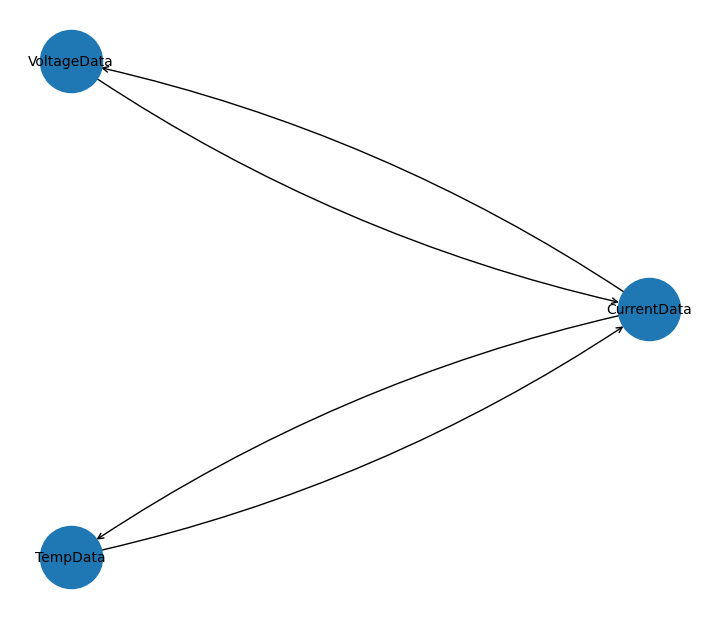

In [14]:
save_graph_plot(cols, dag_pc) 

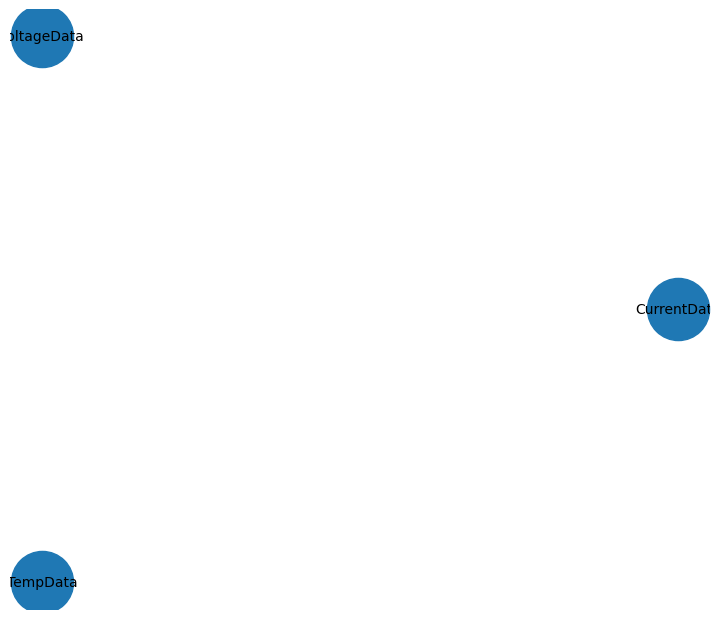

In [15]:
save_graph_plot(cols, dag_notears) 

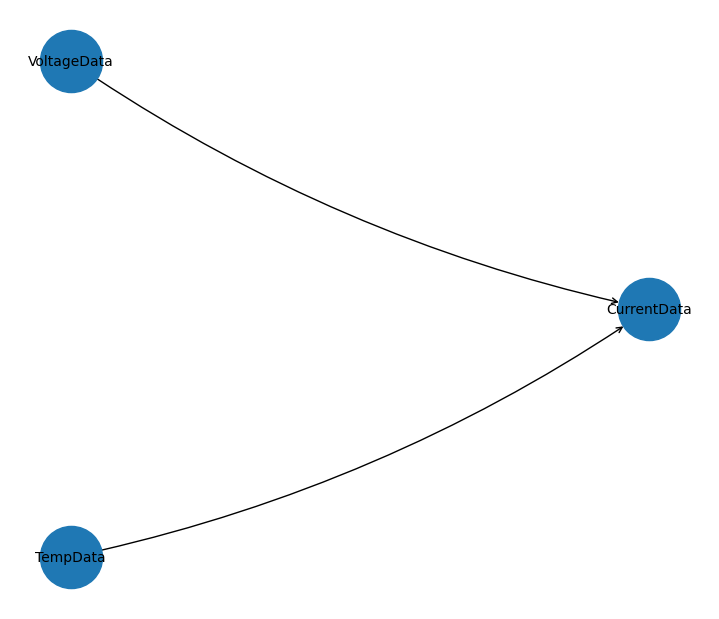

In [16]:
save_graph_plot(cols, dag_dotears) 

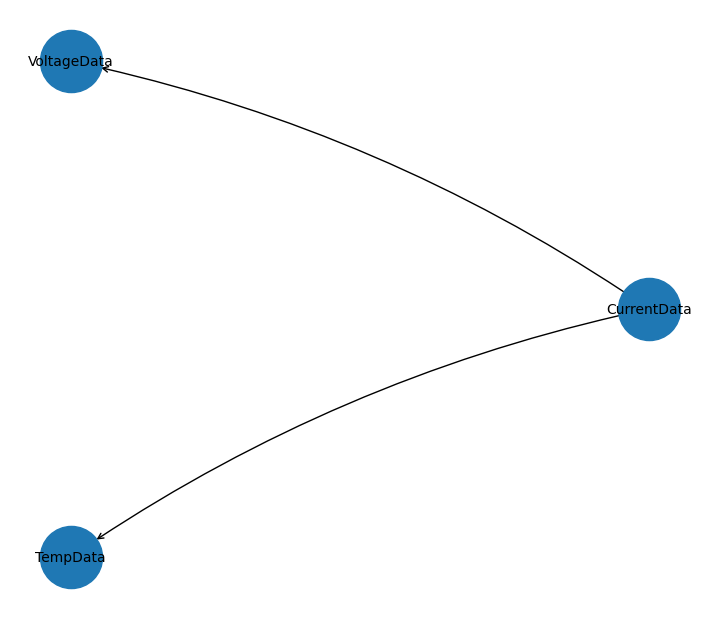

In [17]:
save_graph_plot(cols, dag_dotears2) 